In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


In [3]:

df = pd.read_csv('global_climate_health_impact_tracker_2015_2025.csv')
#df for gloabal climate health impact tracker data

print (df.isnull().sum())
#there are no null values in this dataset

#variables for generic climate/weather information
climate_factors_1 = df[['air_quality_index','precipitation_mm','temperature_celsius','heat_wave_days', 'drought_indicator','flood_indicator']]

# uses the combined variable for exetreme weather events instead of each individually
climate_factors_2 = df[['air_quality_index','precipitation_mm','temperature_celsius','extreme_weather_events']]
 
#uses the 
# our y variable for respiratory disease rate outcomes
resp_disease = df['respiratory_disease_rate']



record_id                       0
country_code                    0
country_name                    0
region                          0
income_level                    0
date                            0
year                            0
month                           0
week                            0
latitude                        0
longitude                       0
population_millions             0
temperature_celsius             0
temp_anomaly_celsius            0
precipitation_mm                0
heat_wave_days                  0
drought_indicator               0
flood_indicator                 0
extreme_weather_events          0
pm25_ugm3                       0
air_quality_index               0
respiratory_disease_rate        0
cardio_mortality_rate           0
vector_disease_risk_score       0
waterborne_disease_incidents    0
heat_related_admissions         0
healthcare_access_index         0
gdp_per_capita_usd              0
mental_health_index             0
food_security_

r squared: 0.5523211742096018
intercept: 51.852130806195504

air_quality_index coef: 0.18638567776298257
precipitation_mm coef: -0.010627165186103984
temperature_celsius coef: 0.044004046803274355
heat_wave_days coef: 1.697452051597777
drought_indicator coef: 1.5908321844092879
flood_indicator coef: 1.1938107522416208


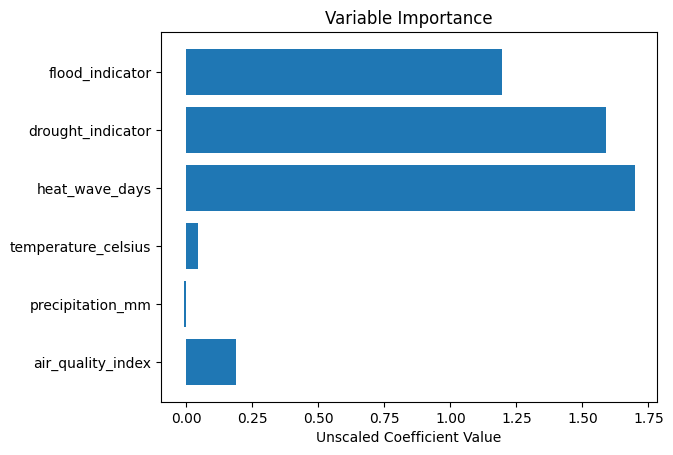

In [ ]:

#Climate model one (unscaled)

#train/test data splitting
X_train, X_test, y_train, y_test = train_test_split(climate_factors_1,resp_disease, test_size= 0.2)

# training model
linear_model  = LinearRegression()
linear_model.fit(X_train, y_train)

#getting predictions of model
y_pred = linear_model.predict(X_test)

#printing r2 score
r2 = r2_score(y_test,y_pred)
print(f'r squared: {r2}')

#getting variable weights
coefs = list(linear_model.coef_)
print(f'intercept: {(linear_model.intercept_)}\n')
for i, f in  enumerate(climate_factors_1): print (f'{f} coef: {coefs[i]}')

#plotting variable weights
plt.barh(list(climate_factors_1), list(coefs))
plt.xlabel("Unscaled Coefficient Value")
plt.title("Variable Importance")
plt.show()




r squared: 0.5503328485788097
intercept: 51.76863039405036

air_quality_index coef: 0.18566348395844026
precipitation_mm coef: -0.01010536646144734
temperature_celsius coef: 0.04511683241573727
extreme_weather_events coef: 1.669919384603561


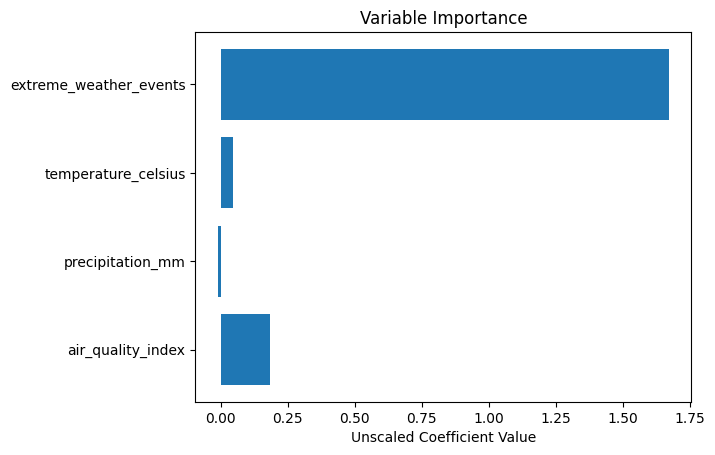

In [ ]:
#climate model 2 (unscaled, combined extreme weather events)
# using the combined extreme weather events and using them individually had essentially no effect on the r^2 outcome

# #train/test data splitting
X_train, X_test, y_train, y_test = train_test_split(climate_factors_2,resp_disease, test_size= 0.2)

# training model
linear_model  = LinearRegression()
linear_model.fit(X_train, y_train)

#getting predictions of model
y_pred = linear_model.predict(X_test)

#printing r2 score
r2 = r2_score(y_test,y_pred)
print(f'r squared: {r2}')

#getting variable weights
coefs = list(linear_model.coef_)
print(f'intercept: {(linear_model.intercept_)}\n')
for i, f in  enumerate(climate_factors_2): print (f'{f} coef: {coefs[i]}')

#plotting variable weights
plt.barh(list(climate_factors_2), list(coefs))
plt.xlabel("Unscaled Coefficient Value")
plt.title("Variable Importance")
plt.show()



Both of these models rely heavily on the binary extreme weather conditions, which doesn't really make sense when we have a variable for the air quality and with the other variables we have. I'm going to try and see if scaling the model has any signifigant impact on what these weights look like on the graph.

r squared: 0.5483678644771379
intercept: 70.1453989361702

air_quality_index coef: 10.993342407018869
precipitation_mm coef: -0.5210796375428453
temperature_celsius coef: 0.5452983643737053
heat_wave_days coef: 0.7993016037407077
drought_indicator coef: 0.19098199233537605
flood_indicator coef: 0.1944846852138037


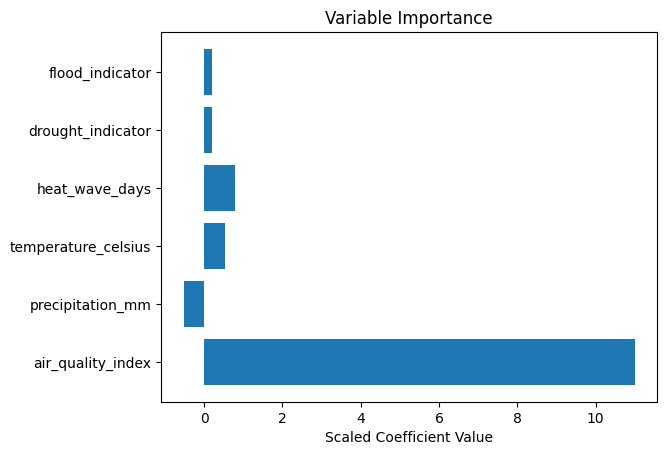

In [ ]:
#climate model 1 (scaled data)
# trying same reggression with scaled data - mainly only affected the intercept, no visible change to r2
# which tells us that under 'normal' or average conditions there are about 70 weekly respitory illness incidents per 100,000 people

#train/test data splitting
X_train, X_test, y_train, y_test = train_test_split(climate_factors_1,resp_disease, test_size= 0.2)

#scaling the data around the mean of each train variable
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# training model
linear_model  = LinearRegression()
linear_model.fit(X_train, y_train)

#getting predictions of model
y_pred = linear_model.predict(X_test)

#printing r2 score
r2 = r2_score(y_test,y_pred)
print(f'r squared: {r2}')

#getting variable weights
coefs = list(linear_model.coef_)
print(f'intercept: {(linear_model.intercept_)}\n')
for i, f in  enumerate(climate_factors_1): print (f'{f} coef: {coefs[i]}')


#plotting variable weights
plt.barh(list(climate_factors_1), list(coefs))
plt.xlabel("Scaled Coefficient Value")
plt.title("Variable Importance")
plt.show()


From the graph we can now see that the air quality has the biggest effect on respiratory outcomes by far, 
followed by days in heatwave and tempature (which go hand in hand) we can also see that the percepitation also tends to lower rates of respitorary illness. Also, the intercept changed from 50 to 70, which indicates that the respiratory illness rate globally under average conditions is about 70 people per 100,000 weekly

r squared: 0.11313015883947852
intercept: 70.06565602836879

precipitation_mm coef: -3.846539339090544
temperature_celsius coef: 4.856291480550318
heat_wave_days coef: 0.0881016197246276
drought_indicator coef: -0.09421305612586517
flood_indicator coef: 0.37227629645777904


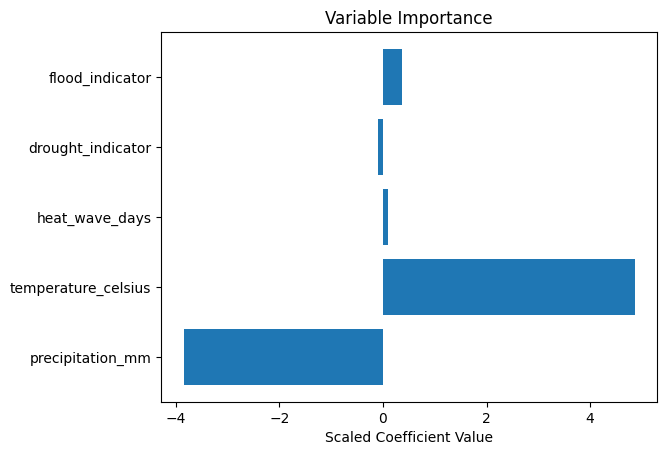

In [143]:
# Im going to try a model without the air quality index to see how well we can predict
# respiratory health outcomes using just the weather and no air quality measurements.
 
#train/test data splitting after removing air quality index
climate_factors_3 = climate_factors_1.drop('air_quality_index', axis = 1)
X_train, X_test, y_train, y_test = train_test_split(climate_factors_3,resp_disease, test_size= 0.2)

# looking at the graph without scaling the data leads to variable weights jumping in all different directions, 
# So I added a scalar for a clean consistent reprisentation of variable weights
#(scaling data on train data)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# training model
linear_model  = LinearRegression()
linear_model.fit(X_train, y_train)

#getting predictions of model
y_pred = linear_model.predict(X_test)

#printing r2 score
r2 = r2_score(y_test,y_pred)
print(f'r squared: {r2}')

#getting variable weights
coefs = list(linear_model.coef_)
print(f'intercept: {(linear_model.intercept_)}\n')
for i, f in  enumerate(climate_factors_3): print (f'{f} coef: {coefs[i]}')

#plotting variable weights
plt.barh(list(climate_factors_3), list(coefs))
plt.xlabel("Scaled Coefficient Value")
plt.title("Variable Importance")
plt.show()

 

Removing air_quality_index made the R² drop sharply to about .11, showing us that weather alone is a weak predictor of respiratory disease rates. Temperature became the main predictor, while the heatwave variable weight dropped to ~0 since it's repetitive with temperature and conveys less information. When left unscaled the model weights jump all over the place with each run, indicating the model is just guessing on the weights for unscaled data, although when we scale the data, the r2 score remains the same but the weights stay much more consistent and we can see the model mainly uses temperature and percipitation when making its predictions.

r squared: 0.5534774208217428
intercept: 70.02959219858157

air_quality_index coef: 10.892136398815502
precipitation_mm coef: -0.33633881800250665
temperature_celsius coef: 0.5892697893368828


Text(0.5, 1.0, 'Variable Importance')

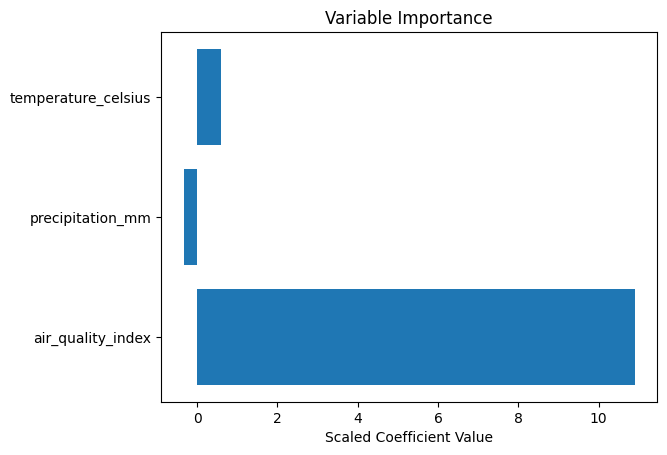

In [ ]:
# after creating this graph I was tempted to try dropping the heatwave indicator and other extreme weather variables 
# to see if I can increase the r2 score by completely removing the variables that overlap with percipitation and temperature
climate_factors_4 = df[['air_quality_index','precipitation_mm','temperature_celsius']]
X_train, X_test, y_train, y_test = train_test_split(climate_factors_4,resp_disease, test_size= 0.2)

# scaling data based on train data means
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# training model
linear_model  = LinearRegression()
linear_model.fit(X_train, y_train)

#getting predictions of model
y_pred = linear_model.predict(X_test)

#printing r2 score
r2 = r2_score(y_test,y_pred)
print(f'r squared: {r2}')

#getting variable weights
coefs = list(linear_model.coef_)
print(f'intercept: {(linear_model.intercept_)}\n')
for i, f in  enumerate(climate_factors_4): print (f'{f} coef: {coefs[i]}')

#plotting variable weights
plt.barh(list(climate_factors_4), list(coefs))
plt.xlabel("Scaled Coefficient Value")
plt.title("Variable Importance")

After Removing the extreme weather variables the r2 score came to approximately the same value as when including them and the scaled coeffecient graph shows us similar metrics weights to the graph that included extreme weather conditions when scaled. In my opinion this fourth model is the strongest because it uses the least amount of information for the same accuracy, and we don't have to worry about overlapping variables, and we can see the cleanest breakdown of variable importance.

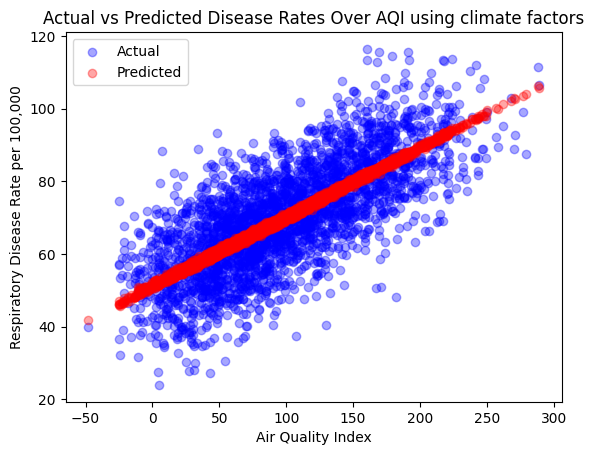

In [370]:
# now using our model I will plot out the estimated and actual heat related admissions over the air quality index (our strongest weighted independent variable), 
# I will do this using an unscaled model version of the fourth model so we can see the appropriate x axis labels


#train/test data splitting
X_train, X_test, y_train, y_test = train_test_split(climate_factors_4,resp_disease, test_size= 0.2)


# training model
linear_model  = LinearRegression()
linear_model.fit(X_train, y_train)


#getting predictions of model
y_pred = linear_model.predict(X_test)


#plotting dependant variabe over strongest independant variable. our predictions and actual outcomes of y
plt.scatter(X_test['air_quality_index'], y_test, 
            color='blue', alpha=0.35, label='Actual')
plt.scatter(X_test['air_quality_index'], y_pred, 
            color='red', alpha=0.35, label='Predicted')

plt.xlabel("Air Quality Index")
plt.ylabel("Respiratory Disease Rate per 100,000")
plt.title("Actual vs Predicted Disease Rates Over AQI using climate factors")
plt.legend()

plt.show()

This visual shows the linear relationship between airquality and respitorary illnesses, and the linear regression model does a pretty good job at capturing this relationship.


Now I will be looking at how socioeconomic factors can effect repiratory illness rates, and how we can use these metrics to build on to our model and improve our accuracy.

r squared: 0.2899024320514739
intercept: 86.16773985923886



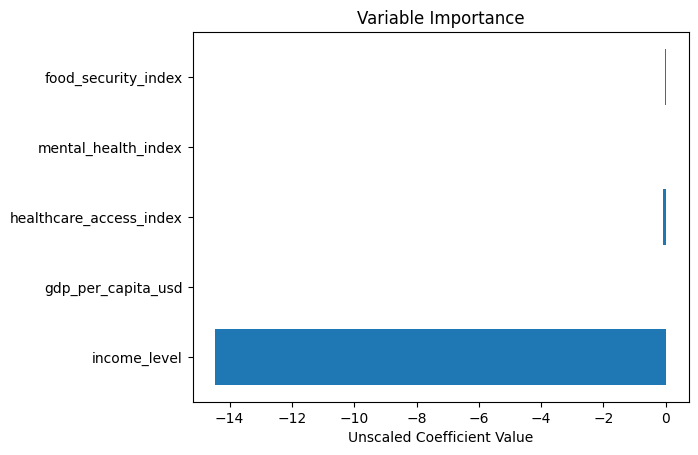

In [147]:
#socioeconomic factors model 1 (unscaled)

# making a new dataframe that changes the income level value into a numerical value
sedf = df.copy()
income_mapping = {
    "Lower-Middle": 0,
    "Upper-Middle": 1,
    "High": 2
}
sedf["income_level"] = df["income_level"].map(income_mapping)

#obtains the x variables from the newly created dataframe
se_factors_1 = sedf[['income_level','gdp_per_capita_usd','healthcare_access_index','mental_health_index','food_security_index']]

#train/test data splitting
X_train, X_test, y_train, y_test = train_test_split(se_factors_1,resp_disease, test_size= 0.2)

# training model
linear_model  = LinearRegression()
linear_model.fit(X_train, y_train)

#getting predictions of model
y_pred = linear_model.predict(X_test)

#getting and printing r2 score
r2 = r2_score(y_test,y_pred)
print(f'r squared: {r2}')

#getting variable weights
coefs = list(linear_model.coef_)
print(f'intercept: {(linear_model.intercept_)}\n')

#plotting variable weights
plt.barh(list(se_factors_1), list(coefs))
plt.xlabel("Unscaled Coefficient Value")
plt.title("Variable Importance")
plt.show()



The r2 is at around .3 which isn't too bad for purely socioeconomic information, although from the chart we can see this model is completely reliant on income level, lets try and scale the data to see if anything changes in variable weights, then play with the variables we use from there . 

r squared: 0.29493356696806783
intercept: 69.92366134751772



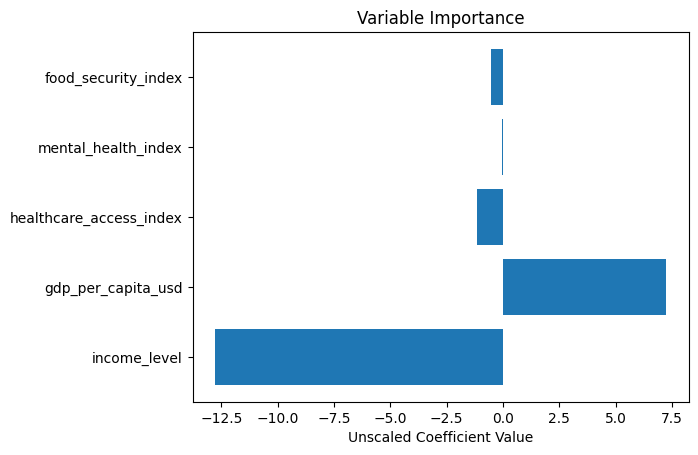

In [ ]:
#socioeconomic factors model 1 (scaled)

#obtains the x variables from the newly created dataframe
se_factors_1 = sedf[['income_level','gdp_per_capita_usd','healthcare_access_index','mental_health_index','food_security_index']]

#train/test data splitting
X_train, X_test, y_train, y_test = train_test_split(se_factors_1,resp_disease, test_size= 0.2)

#(scaling data on train data)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# training model
linear_model  = LinearRegression()
linear_model.fit(X_train, y_train)

#getting predictions of model
y_pred = linear_model.predict(X_test)

#getting and printing r2 score
r2 = r2_score(y_test,y_pred)
print(f'r squared: {r2}')

#getting variable weights
coefs = list(linear_model.coef_)
print(f'intercept: {(linear_model.intercept_)}\n')

#plotting variable weights
plt.barh(list(se_factors_1), list(coefs))
plt.xlabel("Unscaled Coefficient Value")
plt.title("Variable Importance")
plt.show()



With this scaled chart we can see income level still having the largest effect, followed by gdp per capita. And it's interesting to see that these two variables have weights pulling the opposite direction. One reason for this could be that the higher the gdp, the more a person is going to have to leave the house and go work, where thats not necesarilly the case for income level. Also a higher gdp per capita could indicate more industrialized factories and pollution from manufacturing, even if the wealth/ benefits of this manufacturing isn't well distributed amoung its people

r squared: 0.28465876878681085
intercept: 70.07330673758865

income_level coef: -12.711917590846236
gdp_per_capita_usd coef: 7.19439862080463
healthcare_access_index coef: -1.6364698705295524


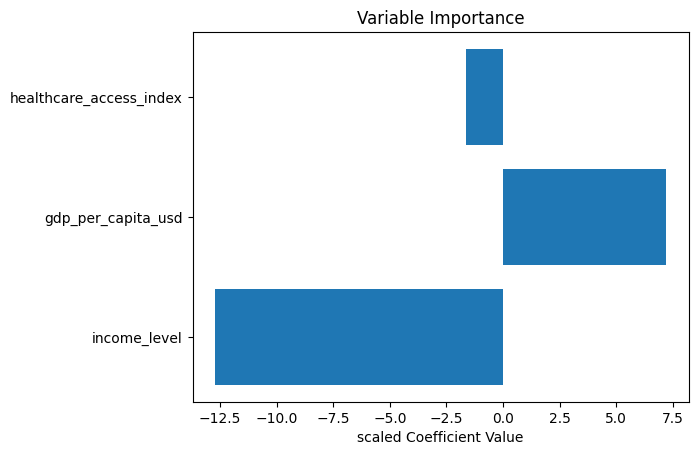

In [276]:
#socioeconomic factors model 2 (scaled)

#obtains the x variables from the newly created dataframe excluding 2 lightest weighing variables in the last run
se_factors_2 = sedf[['income_level','gdp_per_capita_usd','healthcare_access_index']]
X_train, X_test, y_train, y_test = train_test_split(se_factors_2,resp_disease, test_size= 0.2)

#(scaling data on train data)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# training model
linear_model  = LinearRegression()
linear_model.fit(X_train, y_train)

#getting predictions of model
y_pred = linear_model.predict(X_test)

#getting and printing r2 score
r2 = r2_score(y_test,y_pred)
print(f'r squared: {r2}')

#getting variable weights
coefs = list(linear_model.coef_)
print(f'intercept: {(linear_model.intercept_)}\n')
for i, f in  enumerate (se_factors_2): print (f'{f} coef: {coefs[i]}')

#plotting variable weights
plt.barh(list(se_factors_2), list(coefs))
plt.xlabel("scaled Coefficient Value")
plt.title("Variable Importance")
plt.show()

Removing the mental health and food security variables leaves us with a similar r2 value and variable weights while leaving out some of the lightest weighted variables. This is the model I will use for similar reasons of needing less data and avoiding variable overlapping.

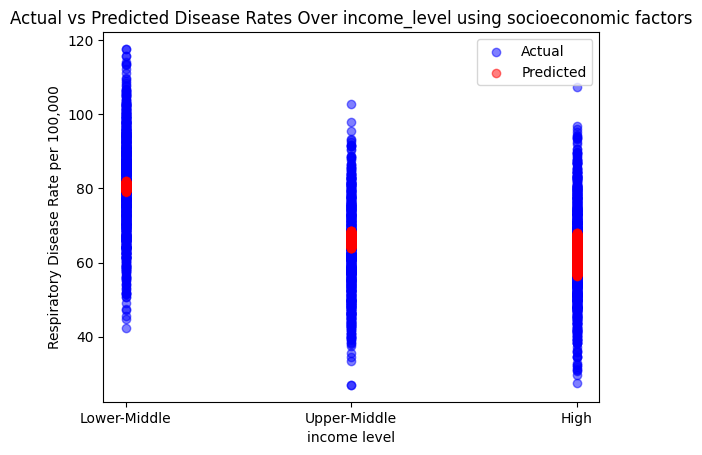

In [ ]:
#I will now show the distrobution of respiratory illness rates across different income levels,
# using the actual rates, and my most recent model's (unscaled version) predictions to visualize how my socioeconomic model's predictions perform. 

#splitting data
X_train, X_test, y_train, y_test = train_test_split(se_factors_2,resp_disease, test_size= 0.2)

# training model
linear_model  = LinearRegression()
linear_model.fit(X_train, y_train)


#getting predictions of model
y_pred = linear_model.predict(X_test)

#plotting dependant variabe over strongest independant variable, both our predictions and actual outcomes of y
plt.scatter(X_test['income_level'], y_test, 
            color='blue', alpha=0.5, label='Actual')
plt.scatter(X_test['income_level'], y_pred, 
            color='red', alpha=0.5, label='Predicted')
plt.xticks(
    ticks=[0, 1, 2],
    labels=["Lower-Middle", "Upper-Middle", "High"])
plt.xlabel("income level")
plt.ylabel("Respiratory Disease Rate per 100,000")
plt.title("Actual vs Predicted Disease Rates Over income_level using socioeconomic factors")
plt.legend()

plt.show()

There is a lot of variablitity that the model is unable to account for although its predictions appear to be near the average respiratory disease rate of each socio economic group, and at least seems reasonable. Combining this with my original model I think will definetely improve its accuracy, although we can see that socioeconomic factors alone do not predict the respiratory disease rate as well as climate factors if the air quality index factors are included. But without the air quality index variable the socioeconomic model outperforms the weather/climate model.

r squared: 0.5392411684683724
intercept: 70.09954787234042

air_quality_index coef: 10.370691286446784
precipitation_mm coef: -0.3808746409027871
temperature_celsius coef: 0.32264014953953324
income_level coef: -2.0226541298474103
gdp_per_capita_usd coef: 1.1168262438709489
healthcare_access_index coef: 0.12308303126928921


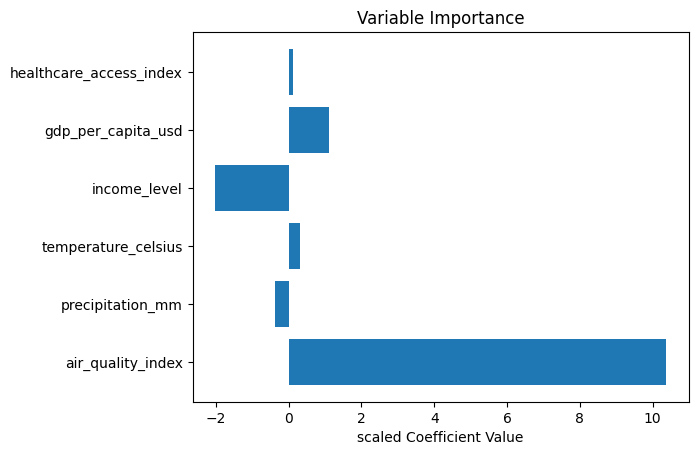

In [354]:
#now I plan to combine socioeconomic factors and climate factors to make a main model with the best ability to predict health outcomes

#This is creating a new dataframe of x variables including both climate and socioeconomic inputs 
model_SEC_var = pd.concat([climate_factors_4, se_factors_2], axis = 1 )

#splitting data
X_train, X_test, y_train, y_test = train_test_split(model_SEC_var,resp_disease, test_size= 0.2)

#scaling data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#training data
linear_model  = LinearRegression()
linear_model.fit(X_train, y_train)

#making predictions on test data
y_pred = linear_model.predict(X_test)

#getting the r2 score
r2 = r2_score(y_test,y_pred)
print(f'r squared: {r2}')

#getting coeffecients
coefs = list(linear_model.coef_)
print(f'intercept: {(linear_model.intercept_)}\n')
for i, f in  enumerate (model_SEC_var): print (f'{f} coef: {coefs[i]}')

#displaying coeffecients
plt.barh(list(model_SEC_var), list(coefs))
plt.xlabel("scaled Coefficient Value")
plt.title("Variable Importance")
plt.show()

unfortanately combining these two models did not have any effect on r2 like I thought it would although we can see that income level and air quality index are doing most of the work in its predicition,
Although we should take one more look at how the predicted and actual values look over the axis of our strongest variable air quality index

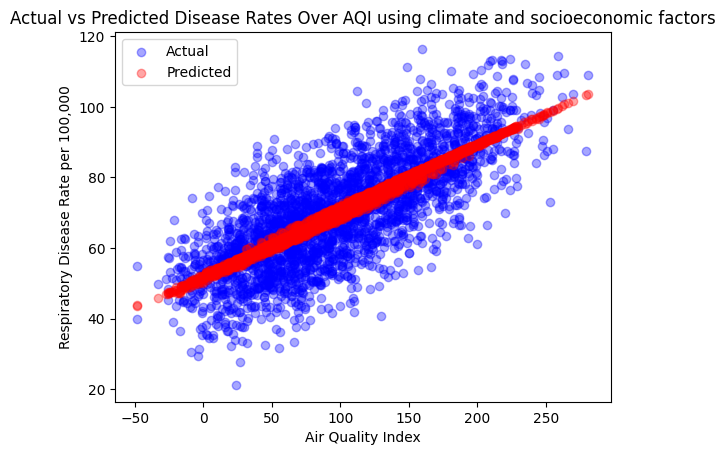

In [373]:
#creating an unscaled version of the most recent model above 

#splitting data
X_train, X_test, y_train, y_test = train_test_split(model_SEC_var,resp_disease, test_size= 0.2)

#training model
linear_model  = LinearRegression()
linear_model.fit(X_train, y_train)

#getting predictions of model
y_pred = linear_model.predict(X_test)


#plotting thepredicted and actual disease rate over the air quality index for that week
plt.scatter(X_test['air_quality_index'], y_test, 
            color='blue', alpha=.35, label='Actual')
plt.scatter(X_test['air_quality_index'], y_pred, 
            color='red', alpha= .35, label='Predicted')

plt.xlabel("Air Quality Index")
plt.ylabel("Respiratory Disease Rate per 100,000")
plt.title("Actual vs Predicted Disease Rates Over AQI using climate and socioeconomic factors")
plt.legend()

plt.show()

we can see the predicted line is a little bit thicker, which indicates there is a little bit more variaety in whats influencing these predictions beyond air quality, but again nowhere close to being able to actually  predict the sheer amount of factors that go into respiratory disease rate.

                respiratory_disease_rate  income_level  gdp_per_capita_usd  \
region                                                                       
South Asia                     81.379905      0.000000         2882.897163   
Southeast Asia                 77.198005      0.250000         6466.433954   
Africa                         76.942243      0.250000         4709.416667   
East Asia                      63.742465      1.500000        41886.818262   
Europe                         63.703333      2.000000        61203.983688   
North America                  63.551655      1.666667        42875.281915   
South America                  63.393262      1.000000        12890.271277   
Oceania                        62.884752      2.000000        47835.338652   

                air_quality_index  
region                             
South Asia             154.710993  
Southeast Asia         132.960993  
Africa                 133.295213  
East Asia               68.878546  
Eur

Text(0.5, 1.0, 'Respiratory disease rate by region')

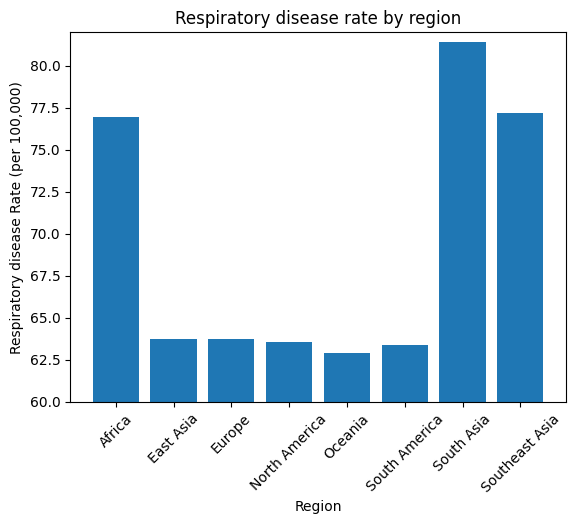

In [ ]:
#now I will look at some geogrpaphical trends of respiratory illness amoung different regions 

#grouping the socioeconomic data (so income level is onumeric) by region and printing the regions in order
#  from highest to lower along with some of the strongest weighted variables from our socio economic/climate model
df_grouped_region = sedf.groupby('region')[['respiratory_disease_rate','income_level','gdp_per_capita_usd','air_quality_index']].mean()
print(df_grouped_region.nlargest(9,'respiratory_disease_rate'))

#plotting out the differences in average respiratory disease rate by region
plt.bar(df_grouped_region.index, df_grouped_region['respiratory_disease_rate'])
plt.xticks(rotation=45)
plt.ylim(60, 82)
plt.xlabel('Region')
plt.ylabel ('Respiratory disease Rate (per 100,000)')
plt.title ('Respiratory disease rate by region')


as we can see south/southeast asia and Africa have the highest rate of respiratory illness by far, and as we could guess when looking at the strongest indicating variables from earlier models, those three regions have the lowest income levels and exceptionally highest air quality indexes (higher is worse), although the gdp is quite lower than in other regions, the difference in air quality and income levels overpower this variable. 

In [ ]:

#grouping the data by country to see some of the countries with the highest respiratory disease rates in the last 10 years
# and also displaying other indicating factors of respiratory disease
df_grouped_country = sedf.groupby(['country_name','region'])[['respiratory_disease_rate','income_level','gdp_per_capita_usd','air_quality_index']].mean()
df_grouped_country.nlargest(15,'respiratory_disease_rate')
#df_grouped_country.nlargest(15,'air_quality_index')
#df_grouped_country.nsmallest(15,'income_level')
#df_grouped_country.nlargest(15,'gdp_per_capita_usd')

,,respiratory_disease_rate,income_level,gdp_per_capita_usd,air_quality_index
country_name,region,,,,
Bangladesh,South Asia,81.911170,0.0,1732.462766,156.558511
Egypt,Africa,81.280319,0.0,4189.432624,154.730496
India,South Asia,81.178191,0.0,2734.799645,154.641844
Indonesia,Southeast Asia,81.960816,0.0,2737.329787,153.331560
Kenya,Africa,81.611170,0.0,2351.108156,155.611702
Nigeria,Africa,81.546454,0.0,2684.414894,156.409574
Pakistan,South Asia,81.050355,0.0,4181.429078,152.932624
Philippines,Southeast Asia,81.500177,0.0,3185.358156,154.789007
Vietnam,Southeast Asia,81.554787,0.0,3728.934397,155.695035


9/10 of the countries with the highest rates of respiratory illness are from the three regions with spikes in air quality index and respiratory illness. They are also the 9 countries with the lowest income level, indicating they are extremely correlated. This makes sense considering combining the two values had minimal effect on the r2 effect when looking at just the air quality index.

# Closing Remarks
This analysis looked at how climate and socioeconomic factors relate to weekly respiratory disease rates across countries from 2015–2025. Air quality (AQI) was consistently the strongest predictor, explaining a the majority of variation in respiratory disease rates. When AQI was removed, weather variables alone (temperature, precipitation, and extreme event indicators) had signifigantly lower predictive power, telling us that short-term respiratory outcomes are much more influenced by air pollution than general weather conditions.

Adding socioeconomic variables did not substantially increase model R2. This suggests that much of their signal is already captured indirectly through air quality measures. Country and region data information was never incorporated into the model (because there would be no order to a numerical scale), after doing some descriptive analysis and we saw the highest rates of air pollution and respiratory disease rates also had the lowest income level, giving us a pretty good picture at how air pollution and income level go hand in hand and giving explanation as to why the r2 didn't show change when combining income level and airquality index, because airquality alone already said a lot about the income level for that country.